# Índice de Caminabilidad — Piloto Av. Roosevelt
**ITT Cali Inteligente · Equipo de Gobierno de Datos**

Este notebook calcula las métricas de caminabilidad para el área de influencia
de la intervención en Av. Roosevelt, usando la red peatonal de OpenStreetMap.

**Sistema de referencia:** WGS84 (EPSG:4326) para toda la información geoespacial.
Se usa EPSG:3116 (Colombia) únicamente para cálculos de área y distancia.

**Datos:** `data/itt_roosevelt/Roosevelt/Geojson_Roosevelt/`

**Instrucciones:**
1. Ejecutar las celdas en orden
2. Los datos se cargan automáticamente
3. Los resultados y mapas se generan automáticamente

## Celda 1 — Instalación de dependencias

In [134]:
import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p in ['osmnx', 'geopandas', 'matplotlib', 'pandas', 'numpy', 'folium', 'seaborn']:
    check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


## Celda 2 — Importaciones y configuración

In [135]:
import os, re, json, warnings, datetime, logging
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import folium
warnings.filterwarnings('ignore')
logging.getLogger('pyogrio').setLevel(logging.ERROR)

# Sistema de referencia
CRS_WGS84 = 'EPSG:4326'      # Sistema de trabajo (geográfico)
CRS_COLOMBIA = 'EPSG:3116'    # Solo para cálculos de área/distancia (proyectado)

plt.rcParams.update({
    'figure.facecolor': '#F4F6F9',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
print(f'Sistema de referencia de trabajo: {CRS_WGS84}')
print(f'Sistema proyectado para cálculos: {CRS_COLOMBIA}')
print('Configuración lista')

Sistema de referencia de trabajo: EPSG:4326
Sistema proyectado para cálculos: EPSG:3116
Configuración lista


## Celda 3 — Parámetros, rutas y detección de entorno

In [136]:
# Repositorio del proyecto
REPO_URL = 'https://github.com/j0rg3c45/indice-caminabilidad-roosevelt.git'
REPO_NAME = 'indice-caminabilidad-roosevelt'

# Detectar entorno: Colab o local
if os.path.exists('/content'):
    import subprocess as _sp
    os.chdir('/content')
    _sp.getoutput(f'rm -rf {REPO_NAME}')
    print(_sp.getoutput(f'git clone {REPO_URL}'))
    PROJECT_ROOT = Path(f'/content/{REPO_NAME}')
else:
    PROJECT_ROOT = Path(os.getcwd()).parent

# Rutas relativas al proyecto
DATA_DIR = PROJECT_ROOT / 'data' / 'itt_roosevelt' / 'Roosevelt' / 'Geojson_Roosevelt'
IMG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'

IMG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Búsqueda flexible de archivos GeoJSON
def find_file(base_dir, pattern):
    regex = re.compile(pattern, re.IGNORECASE)
    for root, _dirs, files in os.walk(base_dir):
        for f in files:
            if regex.search(f) and f.lower().endswith('.geojson'):
                return os.path.join(root, f)
    return None

# Rutas a los archivos de datos
PATHS = {
    'poligono_buffer': find_file(DATA_DIR, r'Geojson_tramos_Roosevelt_Buffer_100'),
    'poligono_tramos': find_file(DATA_DIR, r'Geojson_tramos_Roosevelt\.geojson'),
    'siniestros':      find_file(DATA_DIR, r'BD_SINIESTROS'),
    'comparendos':     find_file(DATA_DIR, r'COMPARENDOS'),
    'homicidios':      find_file(DATA_DIR, r'HOMICIDIOS'),
    'hurtos':          find_file(DATA_DIR, r'HURTOS'),
    'sedes':           find_file(DATA_DIR, r'Sedes_educativas'),
    'vbg':             find_file(DATA_DIR, r'VBG'),
    'vif':             find_file(DATA_DIR, r'VIOLENCIA_INTRAFAMILIAR'),
}

ZONA_NOMBRE = 'Av. Roosevelt — Cali'

print(f'DATA_DIR: {DATA_DIR}')
print(f'IMG_DIR:  {IMG_DIR}')
print(f'RESULTS_DIR: {RESULTS_DIR}')
print()
print('Archivos encontrados:')
for nombre, ruta in PATHS.items():
    ok = ruta is not None and os.path.exists(ruta)
    estado = chr(9989) if ok else chr(10060)
    print(f'  {estado}  {nombre:18s}: {Path(ruta).name if ruta else "NO ENCONTRADO"}')

Cloning into 'indice-caminabilidad-roosevelt'...
DATA_DIR: /content/indice-caminabilidad-roosevelt/data/itt_roosevelt/Roosevelt/Geojson_Roosevelt
IMG_DIR:  /content/indice-caminabilidad-roosevelt/outputs/figures
RESULTS_DIR: /content/indice-caminabilidad-roosevelt/outputs/results

Archivos encontrados:
  ✅  poligono_buffer   : Geojson_tramos_Roosevelt_Buffer_100.geojson
  ✅  poligono_tramos   : Geojson_tramos_Roosevelt.geojson
  ✅  siniestros        : BD_SINIESTROS_2023_2025_COMUNA_BARRIO_4326_Roosevelt.geojson
  ✅  comparendos       : COMPARENDOS_2023_2025_Roosevelt.geojson
  ✅  homicidios        : HOMICIDIOS_2023_2025_Roosevelt.geojson
  ✅  hurtos            : HURTOS_2023_2025_Roosevelt.geojson
  ✅  sedes             : Sedes_educativas_oficiales_Roosevelt.geojson
  ✅  vbg               : VBG_2025_Roosevelt.geojson
  ✅  vif               : VIOLENCIA_INTRAFAMILIAR_2023_2025_Roosevelt.geojson


## Celda 4 — Cargar polígono y asegurar WGS84

In [137]:
# Cargar polígono de intervención (buffer 100m)
gdf_poligono = gpd.read_file(PATHS['poligono_buffer'])

# Asegurar que el polígono esté en WGS84
if gdf_poligono.crs is None:
    print('AVISO: GeoJSON sin CRS definido, asignando WGS84')
    gdf_poligono = gdf_poligono.set_crs(CRS_WGS84)
elif gdf_poligono.crs.to_epsg() != 4326:
    print(f'Reproyectando polígono de {gdf_poligono.crs} a WGS84...')
    gdf_poligono = gdf_poligono.to_crs(CRS_WGS84)

# Polígono en WGS84 para OSMnx y visualización
polygon_wgs84 = gdf_poligono.geometry.iloc[0]

# Proyectar a EPSG:3116 SOLO para cálculos de área/distancia
gdf_proyectado = gdf_poligono.to_crs(CRS_COLOMBIA)
area_m2 = gdf_proyectado.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

print(f'\n=== ÁREA DE INTERVENCIÓN ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  CRS de trabajo: {gdf_poligono.crs}')
print(f'  CRS para cálculos: {CRS_COLOMBIA}')
print(f'  Área: {area_m2:,.0f} m² ({area_m2/10000:.2f} ha)')
if 'BUFF_DIST' in gdf_poligono.columns:
    print(f'  Buffer aplicado: {gdf_poligono["BUFF_DIST"].iloc[0]:.0f} m a cada lado del eje')
if 'Shape_Leng' in gdf_poligono.columns:
    print(f'  Longitud aproximada del corredor: {gdf_poligono["Shape_Leng"].iloc[0]:.0f} m')


=== ÁREA DE INTERVENCIÓN ===
  Zona: Av. Roosevelt — Cali
  CRS de trabajo: EPSG:4326
  CRS para cálculos: EPSG:3116
  Área: 429,014 m² (42.90 ha)
  Buffer aplicado: 100 m a cada lado del eje
  Longitud aproximada del corredor: 1642 m


## Celda 5 — Descargar red peatonal desde OpenStreetMap

In [138]:
# OSMnx requiere el polígono en WGS84 (EPSG:4326)
print(f'Descargando red peatonal (polígono en {CRS_WGS84})...')
G = ox.graph_from_polygon(polygon_wgs84, network_type='walk')
print(f'Red descargada: {len(G.nodes)} nodos, {len(G.edges)} segmentos')
print(f'CRS del grafo: EPSG:4326 (WGS84)')

Descargando red peatonal (polígono en EPSG:4326)...
Red descargada: 246 nodos, 762 segmentos
CRS del grafo: EPSG:4326 (WGS84)


## Celda 6 — Calcular métricas de caminabilidad

In [139]:
# Calcular estadísticas (área en m² para densidades correctas)
stats = ox.basic_stats(G, area=area_m2)

# Exportar red peatonal como GeoJSON en la carpeta de datos de la zona de estudio
gdf_nodos, gdf_aristas = ox.graph_to_gdfs(G)
red_peatonal_path = DATA_DIR / 'red_peatonal_osm_roosevelt.geojson'
gdf_aristas.to_crs(CRS_WGS84).to_file(red_peatonal_path, driver='GeoJSON')
print(f'Red peatonal guardada en zona de estudio: {red_peatonal_path}')

longitud_total_km = stats['edge_length_total'] / 1000
densidad_km_km2 = longitud_total_km / area_km2

metricas_caminabilidad = {
    'Intersecciones peatonales': stats['intersection_count'],
    'Longitud red peatonal (km)': round(longitud_total_km, 2),
    'Longitud promedio segmento (m)': round(stats['edge_length_avg'], 1),
    'Densidad calle (km/km²)': round(densidad_km_km2, 2),
    'Nodos OSM': len(G.nodes),
    'Segmentos OSM': len(G.edges),
}

print('=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS análisis: {CRS_WGS84} | Cálculos métricos: {CRS_COLOMBIA}')
print()
for k, v in metricas_caminabilidad.items():
    print(f'  {k}: {v}')

Red peatonal guardada en zona de estudio: /content/indice-caminabilidad-roosevelt/data/itt_roosevelt/Roosevelt/Geojson_Roosevelt/red_peatonal_osm_roosevelt.geojson
=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===
  Fecha: 2026-05-12
  CRS análisis: EPSG:4326 | Cálculos métricos: EPSG:3116

  Intersecciones peatonales: 232
  Longitud red peatonal (km): 31.78
  Longitud promedio segmento (m): 41.7
  Densidad calle (km/km²): 74.07
  Nodos OSM: 246
  Segmentos OSM: 762


## Celda 7 — Cargar datos geoespaciales complementarios (WGS84)

In [140]:
# Cargar todos los datasets y asegurar WGS84
datasets = {}
print('=== CARGA DE DATASETS (normalizados a WGS84) ===')
print()
for nombre, ruta in PATHS.items():
    if ruta and os.path.exists(ruta) and nombre not in ('poligono_buffer', 'poligono_tramos'):
        try:
            gdf = gpd.read_file(ruta)
            # Asegurar WGS84
            if gdf.crs is None:
                gdf = gdf.set_crs(CRS_WGS84)
            elif gdf.crs.to_epsg() != 4326:
                gdf = gdf.to_crs(CRS_WGS84)
            datasets[nombre] = gdf
            print(f'  {chr(9989)} {nombre:18s}: {len(gdf):>5} registros | CRS: {gdf.crs.to_epsg()}')
        except Exception as e:
            print(f'  {chr(10060)} {nombre:18s}: Error - {e}')

print(f'\nTotal datasets cargados: {len(datasets)}')
print(f'Todos en CRS: {CRS_WGS84}')

=== CARGA DE DATASETS (normalizados a WGS84) ===

  ✅ siniestros        :    72 registros | CRS: 4326
  ✅ comparendos       :  1300 registros | CRS: 4326
  ✅ homicidios        :     5 registros | CRS: 4326
  ✅ hurtos            :   730 registros | CRS: 4326
  ✅ sedes             :     2 registros | CRS: 4326
  ✅ vbg               :     4 registros | CRS: 4326
  ✅ vif               :    24 registros | CRS: 4326

Total datasets cargados: 7
Todos en CRS: EPSG:4326


## Celda 8 — Mapa estático de la red peatonal

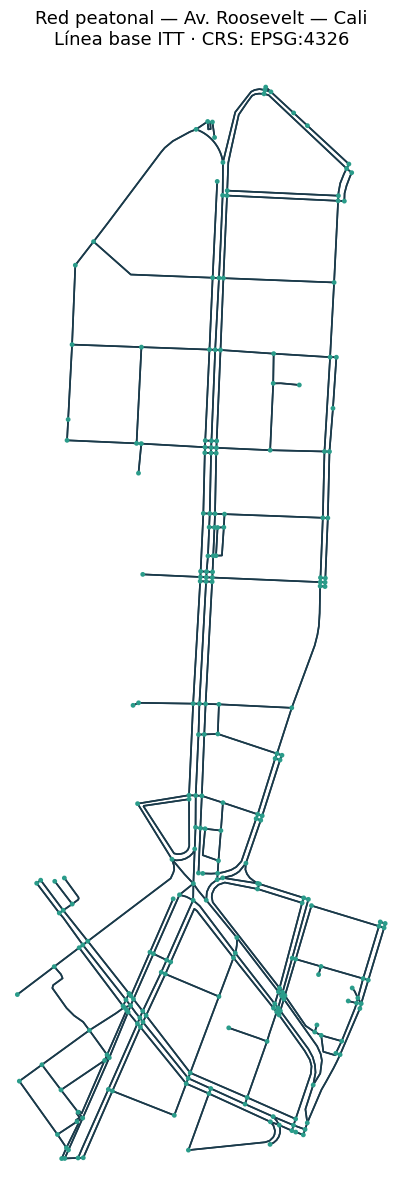

Mapa guardado: /content/indice-caminabilidad-roosevelt/outputs/figures/roosevelt_red_peatonal_linea_base.png


In [141]:
fig, ax = ox.plot_graph(
    G,
    node_size=12,
    edge_linewidth=1.2,
    bgcolor='white',
    node_color='#2A9C8A',
    edge_color='#1A3A4A',
    figsize=(12, 12),
    show=False,
    close=False
)
ax.set_title(
    f'Red peatonal — {ZONA_NOMBRE}\nLínea base ITT · CRS: {CRS_WGS84}',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'roosevelt_red_peatonal_linea_base.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa guardado: {IMG_DIR / "roosevelt_red_peatonal_linea_base.png"}')

## Celda 9 — Mapa interactivo con capas (WGS84)

In [142]:
# Mapa interactivo — todo en WGS84
centroid = polygon_wgs84.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=15,
               tiles=None)

# Capas base
folium.TileLayer('CartoDB positron', name='CartoDB Claro').add_to(m)
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Esri Satélite', overlay=False
).add_to(m)

# Google tiles
google_streets = 'http://{s}.google.com/vt/lyrs=m&x={x}&y={y}&z={z}'
google_satellite = 'http://{s}.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
folium.TileLayer(
    tiles=google_streets,
    attr='Google', name='Google Streets',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)
folium.TileLayer(
    tiles=google_satellite,
    attr='Google', name='Google Satélite',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)

# Polígono de intervención (ya en WGS84)
folium.GeoJson(
    gdf_poligono.__geo_interface__,
    name='Polígono intervención (Buffer 100m)',
    style_function=lambda x: {'color': '#1B4F8A', 'fillColor': '#2E7D32',
                              'fillOpacity': 0.1, 'weight': 2}
).add_to(m)

# Tramos de Roosevelt (eje del corredor)
if PATHS['poligono_tramos'] and os.path.exists(PATHS['poligono_tramos']):
    gdf_tramos = gpd.read_file(PATHS['poligono_tramos'])
    if gdf_tramos.crs is None:
        gdf_tramos = gdf_tramos.set_crs(CRS_WGS84)
    elif gdf_tramos.crs.to_epsg() != 4326:
        gdf_tramos = gdf_tramos.to_crs(CRS_WGS84)
    folium.GeoJson(
        gdf_tramos.__geo_interface__,
        name='Tramos Roosevelt (eje)',
        style_function=lambda x: {'color': '#E53935', 'weight': 4, 'opacity': 0.8}
    ).add_to(m)

# Red peatonal OSM (descargada en Celda 5)
gdf_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
gdf_edges_wgs84 = gdf_edges.to_crs(CRS_WGS84) if gdf_edges.crs.to_epsg() != 4326 else gdf_edges
folium.GeoJson(
    gdf_edges_wgs84[['geometry']].__geo_interface__,
    name='Red peatonal OSM (líneas)',
    style_function=lambda x: {'color': '#2A9C8A', 'weight': 2, 'opacity': 0.7}
).add_to(m)

# Nodos del grafo (intersecciones)
gdf_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_wgs84 = gdf_nodes.to_crs(CRS_WGS84) if gdf_nodes.crs.to_epsg() != 4326 else gdf_nodes
fg_nodos = folium.FeatureGroup(name='Nodos (intersecciones)', show=True)
for _, row in gdf_nodes_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3, color='#E53935', fill=True, fill_opacity=0.9, weight=1
    ).add_to(fg_nodos)
fg_nodos.add_to(m)

# Vértices intermedios de las líneas (todos los puntos que forman cada segmento)
fg_vertices = folium.FeatureGroup(name='Vértices de líneas', show=True)
for _, row in gdf_edges_wgs84.iterrows():
    for coord in list(row.geometry.coords):
        folium.CircleMarker(
            location=[coord[1], coord[0]],
            radius=1.5, color='#1A3A4A', fill=True, fill_opacity=0.7, weight=0.5
        ).add_to(fg_vertices)
fg_vertices.add_to(m)

# Colores por capa
COLORES = {
    'siniestros': 'red', 'comparendos': 'orange', 'homicidios': 'darkred',
    'hurtos': 'purple', 'sedes': 'blue', 'vbg': 'pink', 'vif': 'darkpurple',
}

# Agregar capas (todas en WGS84)
for nombre, gdf in datasets.items():
    fg = folium.FeatureGroup(name=nombre.capitalize(), show=False)
    color = COLORES.get(nombre, 'gray')
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        if geom.geom_type == 'Point':
            folium.CircleMarker(
                location=[geom.y, geom.x],
                radius=3, color=color, fill=True, fill_opacity=0.6
            ).add_to(fg)
    fg.add_to(m)

folium.LayerControl().add_to(m)
print(f'Mapa interactivo generado — CRS: {CRS_WGS84}')
m

Mapa interactivo generado — CRS: EPSG:4326


## Celda 10 — Indicadores complementarios

In [143]:
print('=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS: {CRS_WGS84} (cálculos de densidad con área en {CRS_COLOMBIA})')
print()

indicadores = {}
for nombre, gdf in datasets.items():
    n_registros = len(gdf)
    densidad = n_registros / (area_m2 / 10000)  # por hectárea
    indicadores[nombre] = {'total': n_registros, 'densidad_por_ha': round(densidad, 2)}
    print(f'  {nombre:18s}: {n_registros:>5} registros | {densidad:.2f} por ha')

print()
print('Nota: estos valores constituyen la línea base pre-intervención.')

=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===
  Zona: Av. Roosevelt — Cali
  Fecha: 2026-05-12
  CRS: EPSG:4326 (cálculos de densidad con área en EPSG:3116)

  siniestros        :    72 registros | 1.68 por ha
  comparendos       :  1300 registros | 30.30 por ha
  homicidios        :     5 registros | 0.12 por ha
  hurtos            :   730 registros | 17.02 por ha
  sedes             :     2 registros | 0.05 por ha
  vbg               :     4 registros | 0.09 por ha
  vif               :    24 registros | 0.56 por ha

Nota: estos valores constituyen la línea base pre-intervención.





## Celda 11 — Exportar resultados

In [144]:
resultado = {
    'fecha_medicion': datetime.date.today().isoformat(),
    'poligono': 'Av. Roosevelt - Buffer 100m',
    'crs_trabajo': CRS_WGS84,
    'crs_calculo': CRS_COLOMBIA,
    'area_m2': round(area_m2, 0),
    'area_ha': round(area_m2 / 10000, 2),
    'intersecciones_peatonales': stats['intersection_count'],
    'longitud_red_peatonal_km': round(longitud_total_km, 2),
    'longitud_promedio_segmento_m': round(stats['edge_length_avg'], 1),
    'densidad_calle_km_km2': round(densidad_km_km2, 2),
    'nodos_osm': len(G.nodes),
    'segmentos_osm': len(G.edges),
    'fuente': 'OpenStreetMap via OSMnx',
    'momento': 'linea_base_pre_intervencion',
}

# Agregar conteos complementarios
for nombre, vals in indicadores.items():
    resultado[f'total_{nombre}'] = vals['total']
    resultado[f'densidad_{nombre}_por_ha'] = vals['densidad_por_ha']

df_resultados = pd.DataFrame([resultado])
output_csv = RESULTS_DIR / 'roosevelt_caminabilidad_linea_base.csv'
df_resultados.to_csv(output_csv, index=False)

print(f'Resultados exportados: {output_csv}')
print()
print(df_resultados.T.to_string())

Resultados exportados: /content/indice-caminabilidad-roosevelt/outputs/results/roosevelt_caminabilidad_linea_base.csv

                                                        0
fecha_medicion                                 2026-05-12
poligono                      Av. Roosevelt - Buffer 100m
crs_trabajo                                     EPSG:4326
crs_calculo                                     EPSG:3116
area_m2                                          429014.0
area_ha                                              42.9
intersecciones_peatonales                             232
longitud_red_peatonal_km                            31.78
longitud_promedio_segmento_m                         41.7
densidad_calle_km_km2                               74.07
nodos_osm                                             246
segmentos_osm                                         762
fuente                            OpenStreetMap via OSMnx
momento                       linea_base_pre_intervencion
total_sinie

## Celda 12 — Descarga (solo Google Colab)

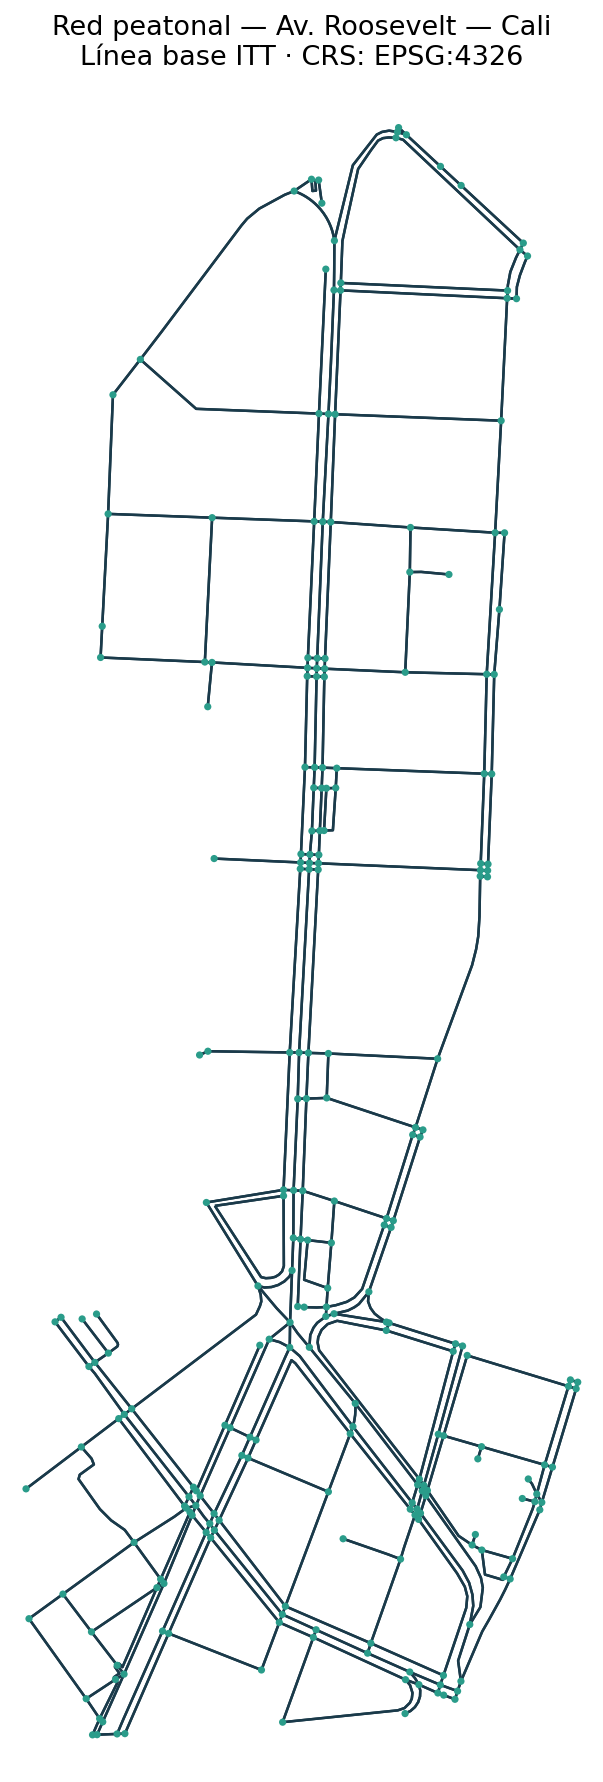


Archivos generados:
  CSV: /content/indice-caminabilidad-roosevelt/outputs/results/roosevelt_caminabilidad_linea_base.csv
  Mapa: /content/indice-caminabilidad-roosevelt/outputs/figures/roosevelt_red_peatonal_linea_base.png


In [145]:
# Mostrar mapa como imagen en el notebook
from IPython.display import Image, display

mapa_path = IMG_DIR / 'roosevelt_red_peatonal_linea_base.png'

if mapa_path.exists():
    display(Image(filename=str(mapa_path), width=800))
else:
    print('Mapa no encontrado. Ejecuta primero la Celda 8.')

print(f'\nArchivos generados:')
print(f'  CSV: {output_csv}')
print(f'  Mapa: {mapa_path}')

# Descarga en Colab (comentado — descomentar si se necesita)
# if os.path.exists('/content'):
#     from google.colab import files
#     files.download(str(output_csv))
#     files.download(str(mapa_path))

---
# GRÁFICOS BASE — Línea Base de Caminabilidad
Los siguientes gráficos constituyen la caracterización espacial y topológica
del corredor Roosevelt para evaluación de impacto y comparación con territorio espejo.

## Gráfico 1 — Mapa de red peatonal (alta resolución)

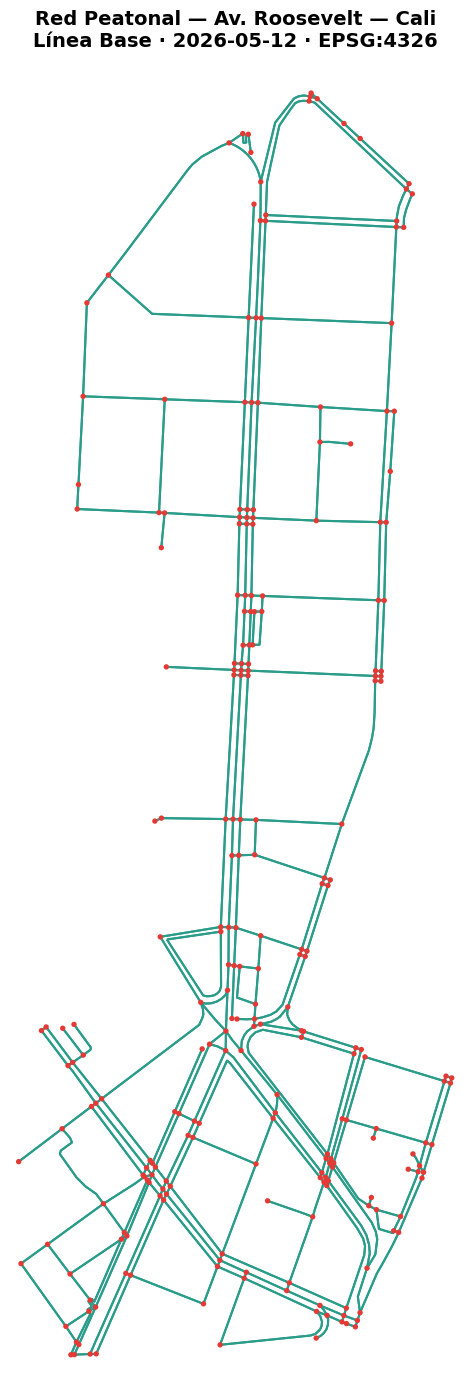

Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_01_red_peatonal.png


In [146]:
# Mapa de red peatonal con nodos, edges y conectividad
fig, ax = ox.plot_graph(
    G,
    node_size=15,
    node_color='#E53935',
    edge_linewidth=1.5,
    edge_color='#2A9C8A',
    bgcolor='white',
    figsize=(14, 14),
    show=False,
    close=False
)
ax.set_title(
    f'Red Peatonal — {ZONA_NOMBRE}\nLínea Base · {datetime.date.today().isoformat()} · {CRS_WGS84}',
    fontsize=14, pad=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_01_red_peatonal.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_01_red_peatonal.png"}')

## Gráfico 2 — Heatmap de densidad de intersecciones

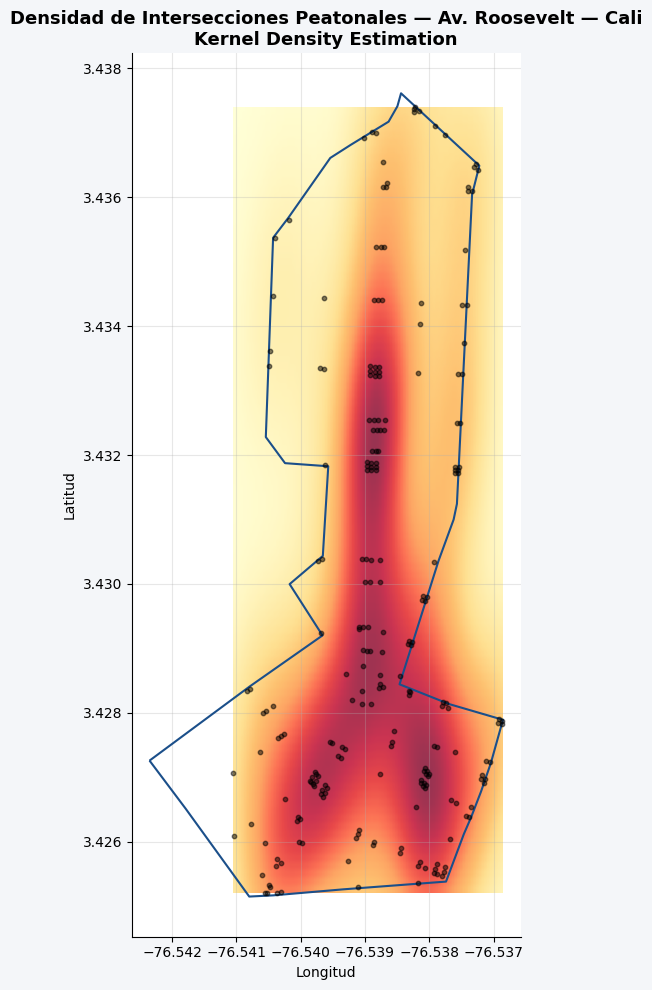

Intersecciones analizadas: 232
Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_02_heatmap_intersecciones.png


In [147]:
# Heatmap de densidad de intersecciones (Kernel Density)
from scipy.stats import gaussian_kde

# Obtener nodos que son intersecciones (degree > 1)
gdf_nodes_all = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_all = gdf_nodes_all.to_crs(CRS_WGS84)

# Filtrar intersecciones (street_count > 2)
if 'street_count' in gdf_nodes_all.columns:
    intersecciones = gdf_nodes_all[gdf_nodes_all['street_count'] > 2]
else:
    intersecciones = gdf_nodes_all

x = intersecciones.geometry.x.values
y = intersecciones.geometry.y.values

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

if len(x) > 5:
    # Kernel Density Estimation
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(positions).reshape(xx.shape)
    
    ax.imshow(np.rot90(density), extent=[xmin, xmax, ymin, ymax],
              cmap='YlOrRd', aspect='auto', alpha=0.8)
    ax.scatter(x, y, s=10, c='black', alpha=0.5, zorder=5)
else:
    ax.scatter(x, y, s=30, c='red')

# Polígono de referencia
gdf_poligono.boundary.plot(ax=ax, color='#1B4F8A', linewidth=1.5)

ax.set_title(f'Densidad de Intersecciones Peatonales — {ZONA_NOMBRE}\nKernel Density Estimation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_02_heatmap_intersecciones.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Intersecciones analizadas: {len(intersecciones)}')
print(f'Exportado: {IMG_DIR / "graf_02_heatmap_intersecciones.png"}')

## Gráfico 3 — Histograma de longitud de segmentos

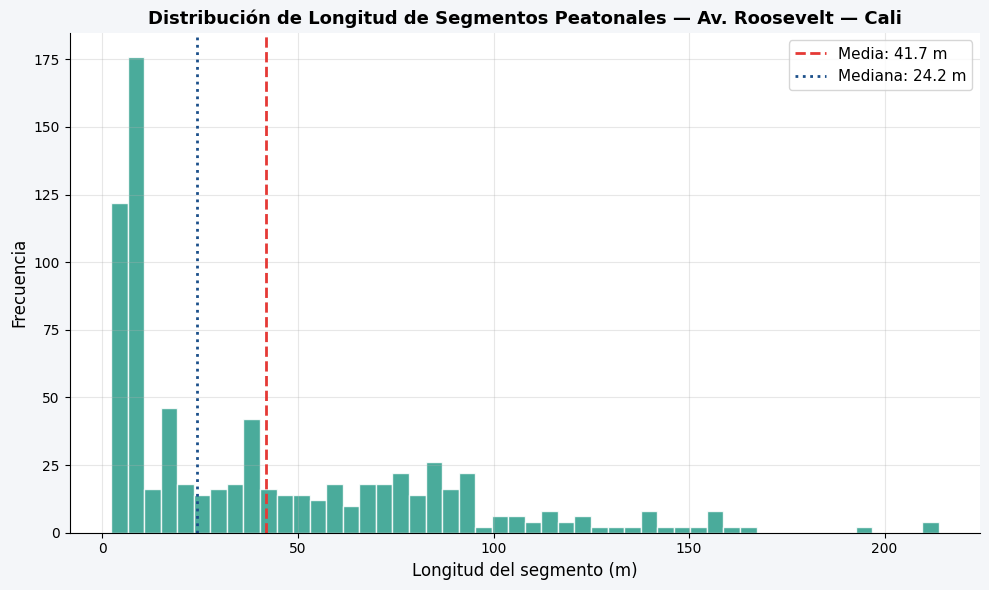

Segmentos: 762 | Media: 41.7m | Mediana: 24.2m
Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_03_histograma_segmentos.png


In [148]:
# Histograma de longitud de segmentos peatonales
gdf_edges_all = ox.graph_to_gdfs(G, nodes=False, edges=True)
longitudes = gdf_edges_all['length'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(longitudes, bins=50, color='#2A9C8A', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(longitudes), color='#E53935', linestyle='--', linewidth=2,
           label=f'Media: {np.mean(longitudes):.1f} m')
ax.axvline(np.median(longitudes), color='#1B4F8A', linestyle=':', linewidth=2,
           label=f'Mediana: {np.median(longitudes):.1f} m')

ax.set_xlabel('Longitud del segmento (m)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Distribución de Longitud de Segmentos Peatonales — {ZONA_NOMBRE}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_03_histograma_segmentos.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Segmentos: {len(longitudes)} | Media: {np.mean(longitudes):.1f}m | Mediana: {np.median(longitudes):.1f}m')
print(f'Exportado: {IMG_DIR / "graf_03_histograma_segmentos.png"}')

## Gráfico 4 — Boxplot de segmentos peatonales

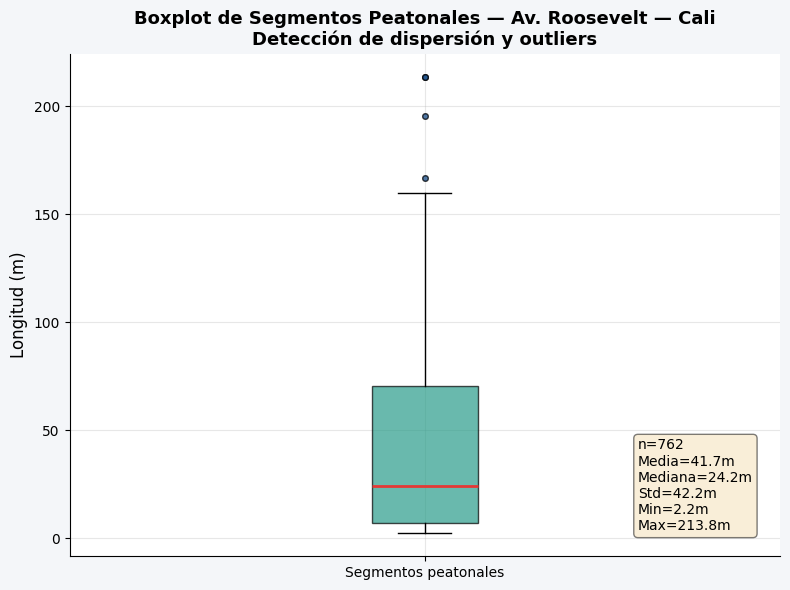

Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_04_boxplot_segmentos.png


In [149]:
# Boxplot de longitud de segmentos
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(longitudes, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2A9C8A', alpha=0.7),
                medianprops=dict(color='#E53935', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#1B4F8A', markersize=4, alpha=0.5))

ax.set_ylabel('Longitud (m)', fontsize=12)
ax.set_title(f'Boxplot de Segmentos Peatonales — {ZONA_NOMBRE}\nDetección de dispersión y outliers',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(['Segmentos peatonales'])

# Estadísticas en el gráfico
stats_text = (f'n={len(longitudes)}\n'
              f'Media={np.mean(longitudes):.1f}m\n'
              f'Mediana={np.median(longitudes):.1f}m\n'
              f'Std={np.std(longitudes):.1f}m\n'
              f'Min={np.min(longitudes):.1f}m\n'
              f'Max={np.max(longitudes):.1f}m')
ax.text(1.3, np.median(longitudes), stats_text, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_04_boxplot_segmentos.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_04_boxplot_segmentos.png"}')

## Gráfico 5 — Scatter plot de conectividad

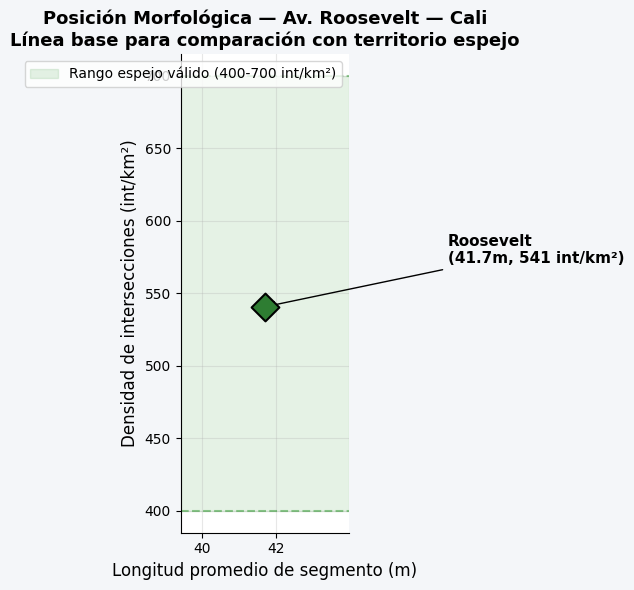

Longitud promedio: 41.7 m
Densidad intersecciones: 541 int/km²
Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_05_scatter_conectividad.png


In [150]:
# Scatter plot: longitud promedio vs densidad de intersecciones
# Posición morfológica de Roosevelt (punto único para línea base)
long_prom = np.mean(longitudes)
densidad_intersecciones = stats['intersection_count'] / area_km2

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(long_prom, densidad_intersecciones, s=200, c='#2E7D32', marker='D',
           edgecolors='black', linewidth=1.5, zorder=5)
ax.annotate(f'Roosevelt\n({long_prom:.1f}m, {densidad_intersecciones:.0f} int/km²)',
            xy=(long_prom, densidad_intersecciones),
            xytext=(long_prom + 5, densidad_intersecciones + 30),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

# Zonas de referencia
ax.axhspan(400, 700, alpha=0.1, color='green', label='Rango espejo válido (400-700 int/km²)')
ax.axhline(400, color='green', linestyle='--', alpha=0.4)
ax.axhline(700, color='green', linestyle='--', alpha=0.4)

ax.set_xlabel('Longitud promedio de segmento (m)', fontsize=12)
ax.set_ylabel('Densidad de intersecciones (int/km²)', fontsize=12)
ax.set_title(f'Posición Morfológica — {ZONA_NOMBRE}\nLínea base para comparación con territorio espejo',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_05_scatter_conectividad.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Longitud promedio: {long_prom:.1f} m')
print(f'Densidad intersecciones: {densidad_intersecciones:.0f} int/km²')
print(f'Exportado: {IMG_DIR / "graf_05_scatter_conectividad.png"}')

## Gráfico 6 — Tabla resumen de métricas urbanas

=== TABLA RESUMEN — Av. Roosevelt — Cali ===
Fecha: 2026-05-12 | CRS: EPSG:4326

                             Métrica   Valor
                     Área total (ha)  42.900
                    Área total (km²)   0.429
           Intersecciones peatonales 232.000
          Longitud total de red (km)  31.780
      Longitud promedio segmento (m)  41.700
                Mediana segmento (m)  24.200
          Densidad de calle (km/km²)  74.070
Densidad de intersecciones (int/km²) 541.000
                           Nodos OSM 246.000
                       Segmentos OSM 762.000

Exportado: /content/indice-caminabilidad-roosevelt/outputs/results/roosevelt_tabla_resumen_metricas.csv


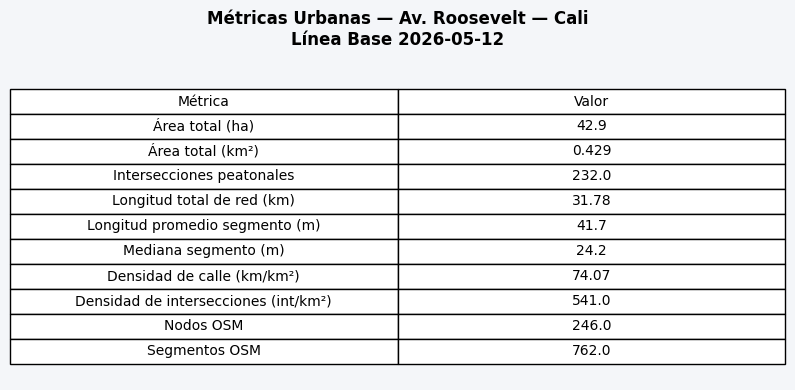

Exportado: /content/indice-caminabilidad-roosevelt/outputs/figures/graf_06_tabla_metricas.png


In [151]:
# Tabla resumen consolidada
densidad_intersecciones_km2 = stats['intersection_count'] / area_km2

tabla_resumen = pd.DataFrame({
    'Métrica': [
        'Área total (ha)',
        'Área total (km²)',
        'Intersecciones peatonales',
        'Longitud total de red (km)',
        'Longitud promedio segmento (m)',
        'Mediana segmento (m)',
        'Densidad de calle (km/km²)',
        'Densidad de intersecciones (int/km²)',
        'Nodos OSM',
        'Segmentos OSM',
    ],
    'Valor': [
        round(area_m2 / 10000, 2),
        round(area_km2, 4),
        stats['intersection_count'],
        round(longitud_total_km, 2),
        round(np.mean(longitudes), 1),
        round(np.median(longitudes), 1),
        round(densidad_km_km2, 2),
        round(densidad_intersecciones_km2, 0),
        len(G.nodes),
        len(G.edges),
    ]
})

print(f'=== TABLA RESUMEN — {ZONA_NOMBRE} ===')
print(f'Fecha: {datetime.date.today().isoformat()} | CRS: {CRS_WGS84}')
print()
print(tabla_resumen.to_string(index=False))

# Exportar CSV
tabla_resumen.to_csv(RESULTS_DIR / 'roosevelt_tabla_resumen_metricas.csv', index=False)
print(f'\nExportado: {RESULTS_DIR / "roosevelt_tabla_resumen_metricas.csv"}')

# Exportar como imagen (tabla)
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(cellText=tabla_resumen.values, colLabels=tabla_resumen.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title(f'Métricas Urbanas — {ZONA_NOMBRE}\nLínea Base {datetime.date.today().isoformat()}',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_06_tabla_metricas.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_06_tabla_metricas.png"}')

---
# TERRITORIOS ESPEJO — Caminabilidad Calle 5 y Calle 7
Cálculo de métricas de caminabilidad para los territorios espejo candidatos
y comparación directa con Av. Roosevelt.

## Celda 13 — Configuración de zonas espejo

In [ ]:
# Rutas a polígonos y datos de zonas espejo
# Los polígonos están como GeoJSON en data/processed/
# Los datos filtrados están en subcarpetas geojson_filtrado_*
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

ZONAS_ESPEJO = {
    'Calle 5': {
        'poligono': PROCESSED_DIR / 'Filtro_Calle_5' / 'calle_5_area_Espejo_Bf100.geojson',
        'geojson_dir': PROCESSED_DIR / 'Filtro_Calle_5' / 'geojson_filtrado_calle_5_area_Espejo_Bf100',
    },
    'Calle 7': {
        'poligono': PROCESSED_DIR / 'Filtro_Calle_7' / 'calle_7_area_Espejo_Bf100.geojson',
        'geojson_dir': PROCESSED_DIR / 'Filtro_Calle_7' / 'geojson_filtrado_calle_7_area_Espejo_Bf100',
    },
}

print('Zonas espejo configuradas:')
for nombre, config in ZONAS_ESPEJO.items():
    existe_pol = config['poligono'].exists()
    existe_datos = config['geojson_dir'].exists()
    print(f'  {chr(9989) if existe_pol else chr(10060)} {nombre} polígono: {config["poligono"].name}')
    print(f'    {chr(9989) if existe_datos else chr(10060)} datos: {config["geojson_dir"].name}')
    if not existe_pol:
        print(f'    ⚠ Ejecuta: uv run notebooks_py/convertir_poligonos_espejo.py')

## Celda 14 — Calcular caminabilidad para cada zona espejo

In [ ]:
# Calcular métricas de caminabilidad para cada territorio espejo
resultados_espejo = []
grafos_espejo = {}

for nombre, config in ZONAS_ESPEJO.items():
    print(f'\n{"═" * 50}')
    print(f'  ZONA ESPEJO: {nombre}')
    print(f'{"═" * 50}')
    
    if not config['poligono'].exists():
        print(f'  ⚠ Polígono no encontrado')
        continue
    
    # Cargar polígono
    gdf_esp = gpd.read_file(config['poligono'])
    if gdf_esp.crs is None:
        gdf_esp = gdf_esp.set_crs(CRS_WGS84)
    elif gdf_esp.crs.to_epsg() != 4326:
        gdf_esp = gdf_esp.to_crs(CRS_WGS84)
    
    polygon_esp = gdf_esp.geometry.iloc[0]
    gdf_esp_m = gdf_esp.to_crs(CRS_COLOMBIA)
    area_esp_m2 = gdf_esp_m.geometry.area.iloc[0]
    area_esp_km2 = area_esp_m2 / 1_000_000
    
    print(f'  Área: {area_esp_m2:,.0f} m² ({area_esp_m2/10000:.2f} ha)')
    
    # Descargar red peatonal
    print(f'  Descargando red peatonal OSM (simplify=False)...')
    G_esp = ox.graph_from_polygon(polygon_esp, network_type='walk', simplify=False)
    grafos_espejo[nombre] = G_esp
    print(f'  Nodos: {len(G_esp.nodes)} | Segmentos: {len(G_esp.edges)}')
    
    # Métricas
    stats_esp = ox.basic_stats(G_esp, area=area_esp_m2)
    gdf_edges_esp = ox.graph_to_gdfs(G_esp, nodes=False, edges=True)
    long_esp = gdf_edges_esp['length'].values
    longitud_total_esp = stats_esp['edge_length_total'] / 1000
    densidad_esp = longitud_total_esp / area_esp_km2
    densidad_int_esp = stats_esp['intersection_count'] / area_esp_km2
    
    metricas_esp = {
        'zona': nombre,
        'fecha_medicion': datetime.date.today().isoformat(),
        'area_ha': round(area_esp_m2 / 10000, 2),
        'intersecciones_peatonales': stats_esp['intersection_count'],
        'densidad_intersecciones_km2': round(densidad_int_esp, 0),
        'longitud_red_peatonal_km': round(longitud_total_esp, 2),
        'longitud_promedio_segmento_m': round(np.mean(long_esp), 1),
        'mediana_segmento_m': round(np.median(long_esp), 1),
        'densidad_calle_km_km2': round(densidad_esp, 2),
        'nodos_osm': len(G_esp.nodes),
        'segmentos_osm': len(G_esp.edges),
    }
    
    # Contar eventos por dataset
    if config['geojson_dir'].exists():
        print(f'  Contando eventos complementarios...')
        for f in sorted(config['geojson_dir'].glob('*.geojson')):
            gdf_ev = gpd.read_file(f)
            dataset_name = f.stem.split('_filtrado_')[0]
            metricas_esp[f'total_{dataset_name}'] = len(gdf_ev)
            print(f'    {dataset_name}: {len(gdf_ev)}')
    
    resultados_espejo.append(metricas_esp)
    print(f'\n  ✓ {nombre} completado')

df_espejo = pd.DataFrame(resultados_espejo)
print(f'\n\nResultados espejo:')
print(df_espejo[['zona','area_ha','intersecciones_peatonales','longitud_red_peatonal_km',
                 'longitud_promedio_segmento_m','densidad_calle_km_km2','densidad_intersecciones_km2']].to_string(index=False))

## Celda 15 — Comparación Roosevelt vs Territorios Espejo

In [ ]:
# Construir tabla comparativa
metricas_roosevelt = {
    'zona': 'Av. Roosevelt',
    'area_ha': round(area_m2 / 10000, 2),
    'intersecciones_peatonales': stats['intersection_count'],
    'densidad_intersecciones_km2': round(stats['intersection_count'] / area_km2, 0),
    'longitud_red_peatonal_km': round(longitud_total_km, 2),
    'longitud_promedio_segmento_m': round(np.mean(longitudes), 1),
    'mediana_segmento_m': round(np.median(longitudes), 1),
    'densidad_calle_km_km2': round(densidad_km_km2, 2),
    'nodos_osm': len(G.nodes),
    'segmentos_osm': len(G.edges),
}

df_comparacion = pd.concat([
    pd.DataFrame([metricas_roosevelt]),
    df_espejo
], ignore_index=True)

cols_mostrar = ['zona', 'area_ha', 'intersecciones_peatonales', 'densidad_intersecciones_km2',
                'longitud_red_peatonal_km', 'longitud_promedio_segmento_m', 'densidad_calle_km_km2']

print('=' * 70)
print('COMPARACIÓN: Av. Roosevelt vs Territorios Espejo')
print(f'Fecha: {datetime.date.today().isoformat()} | CRS: {CRS_WGS84}')
print('=' * 70)
print()
print(df_comparacion[cols_mostrar].to_string(index=False))

# Validación según parámetros del territorio espejo
print('\n' + '─' * 70)
print('VALIDACIÓN (criterios: 400-700 int/km², área 38-48 ha)')
print('─' * 70)
for _, row in df_comparacion.iterrows():
    zona = row['zona']
    dens = row['densidad_intersecciones_km2']
    area = row['area_ha']
    valido_dens = 400 <= dens <= 700
    valido_area = 38 <= area <= 48
    estado = '✓ VÁLIDO' if (valido_dens and valido_area) else '✗ FUERA DE RANGO'
    print(f'  {zona:20s} | Dens: {dens:.0f} int/km² {"✓" if valido_dens else "✗"} | Área: {area:.1f} ha {"✓" if valido_area else "✗"} | {estado}')

## Celda 16 — Gráfico comparativo de conectividad

In [ ]:
# Scatter plot comparativo: Roosevelt vs Espejo
fig, ax = plt.subplots(figsize=(10, 7))

colores = {'Av. Roosevelt': '#2E7D32', 'Calle 5': '#E53935', 'Calle 7': '#1B4F8A'}
marcadores = {'Av. Roosevelt': 'D', 'Calle 5': 'o', 'Calle 7': 's'}

for _, row in df_comparacion.iterrows():
    zona = row['zona']
    ax.scatter(
        row['longitud_promedio_segmento_m'],
        row['densidad_intersecciones_km2'],
        s=250, c=colores.get(zona, 'gray'),
        marker=marcadores.get(zona, 'o'),
        edgecolors='black', linewidth=1.5, zorder=5,
        label=f"{zona} ({row['densidad_intersecciones_km2']:.0f} int/km²)"
    )

# Zona válida para espejo
ax.axhspan(400, 700, alpha=0.08, color='green', label='Rango espejo válido (400-700 int/km²)')
ax.axhline(400, color='green', linestyle='--', alpha=0.3)
ax.axhline(700, color='green', linestyle='--', alpha=0.3)

ax.set_xlabel('Longitud promedio de segmento (m)', fontsize=12)
ax.set_ylabel('Densidad de intersecciones (int/km²)', fontsize=12)
ax.set_title('Comparación Morfológica — Roosevelt vs Territorios Espejo\nLínea Base Caminabilidad',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_07_comparacion_espejo.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_07_comparacion_espejo.png"}')

## Celda 17 — Exportar comparación final

In [ ]:
# Exportar CSV comparativo
output_comparacion = RESULTS_DIR / 'comparacion_roosevelt_vs_espejo.csv'
df_comparacion.to_csv(output_comparacion, index=False)
print(f'CSV comparativo exportado: {output_comparacion}')

# Exportar espejo individual
output_espejo = RESULTS_DIR / 'espejo_caminabilidad_linea_base.csv'
df_espejo.to_csv(output_espejo, index=False)
print(f'CSV espejo exportado: {output_espejo}')

print('\n✓ Análisis de territorios espejo completado.')